
# Part B — 11b Probability & Interval Calibration

## Goal

Notebook 11 showed that the production benchmark should remain **probabilistic climatology**, but its nominal **80% prediction interval only covered about 68% of historical winters**.

That means the interval was too narrow.

This notebook calibrates the snowfall uncertainty using only **past walk-forward forecast errors**.

We compare two leakage-safe calibration strategies:

1. **Conformalized climatology interval**
   - start with the existing empirical 10th–90th percentile interval,
   - measure how far historical observations fell outside it,
   - expand future intervals by a conformal calibration amount.

2. **Symmetric conformal interval**
   - center the interval on the climatological point forecast,
   - use historical absolute forecast errors to determine the radius.

## Important

Calibration is performed in an **expanding / prequential** way:

```text
past forecast errors
        ↓
calibrate interval for next winter
        ↓
observe next winter
        ↓
add its error to calibration history
        ↓
repeat
```

No future winter is allowed to calibrate an earlier forecast.


In [1]:

from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 190)

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
REPORTS_DIR = PROJECT_ROOT / "reports"
MODELS_DIR = PROJECT_ROOT / "models"

for directory in [PROCESSED_DIR, FIGURES_DIR, REPORTS_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

BACKTEST_PATH = (
    PROCESSED_DIR
    / "probabilistic_walk_forward_predictions.csv"
)

NEXT_OUTLOOK_PATH = (
    PROCESSED_DIR
    / "next_season_climatology_outlook.csv"
)

if not BACKTEST_PATH.exists():
    raise FileNotFoundError(
        "probabilistic_walk_forward_predictions.csv was not found. "
        "Run 11_probabilistic_snowfall_forecast.ipynb first."
    )

if not NEXT_OUTLOOK_PATH.exists():
    raise FileNotFoundError(
        "next_season_climatology_outlook.csv was not found. "
        "Run notebook 11 first."
    )

print("Project root:", PROJECT_ROOT)


Project root: /Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis


## 1. Load probabilistic climatology backtest

In [2]:

all_predictions = pd.read_csv(BACKTEST_PATH)

clim = (
    all_predictions[
        all_predictions["method"]
        == "Probabilistic Climatology"
    ]
    .copy()
    .sort_values("season_year")
    .reset_index(drop=True)
)

required = [
    "season_year",
    "actual_cm",
    "point_prediction_cm",
    "lower80_cm",
    "upper80_cm",
]

missing = [
    col for col in required
    if col not in clim.columns
]

if missing:
    raise KeyError(
        f"Missing required columns: {missing}"
    )

print("Climatology backtest winters:", len(clim))
print(
    "Backtest range:",
    clim["season_year"].min(),
    "→",
    clim["season_year"].max()
)

display(
    clim[
        required
    ].head(10)
)


Climatology backtest winters: 50
Backtest range: 1971 → 2026


,season_year,actual_cm,point_prediction_cm,lower80_cm,upper80_cm
0,1971,171.7,133.710000,95.44,182.64
1,1972,188.9,133.966667,95.44,182.64
2,1973,110.0,137.033333,95.44,185.21
3,1974,127.8,134.620000,95.44,185.21
4,1975,124.6,134.756667,95.44,185.21
5,1976,163.3,133.500000,95.44,185.21
6,1977,122.5,135.960000,100.96,185.21
7,1978,143.1,135.150000,100.96,185.21
8,1979,130.7,135.856667,100.96,185.21
9,1980,79.7,135.996667,100.96,185.21


## 2. Reproduce the original nominal 80% interval performance

In [3]:

clim["original_inside_80"] = (
    (clim["actual_cm"] >= clim["lower80_cm"])
    & (clim["actual_cm"] <= clim["upper80_cm"])
)

clim["original_width_cm"] = (
    clim["upper80_cm"]
    - clim["lower80_cm"]
)

original_coverage = (
    clim["original_inside_80"].mean()
)

original_width = (
    clim["original_width_cm"].mean()
)

print(
    f"Original nominal 80% interval coverage: "
    f"{original_coverage:.1%}"
)

print(
    f"Original mean interval width: "
    f"{original_width:.1f} cm"
)


Original nominal 80% interval coverage: 68.0%
Original mean interval width: 81.2 cm



The intended coverage is **80%**.

If observed historical coverage is materially below 80%, the uncertainty band is under-dispersed: it is too narrow for the actual forecast errors.


## 3. Define finite-sample conformal quantile

In [4]:

ALPHA = 0.20
TARGET_COVERAGE = 1 - ALPHA
MIN_CALIBRATION = 15


def conformal_quantile(scores, alpha=ALPHA):
    """
    Finite-sample split-conformal quantile.

    For n calibration scores, use rank:
        ceil((n + 1) * (1 - alpha))

    capped at n.
    """
    scores = np.asarray(scores, dtype=float)
    scores = scores[np.isfinite(scores)]

    n = len(scores)

    if n == 0:
        return np.nan

    rank = math.ceil(
        (n + 1) * (1 - alpha)
    )

    rank = min(rank, n)

    return float(
        np.sort(scores)[rank - 1]
    )


print("Target interval coverage:", f"{TARGET_COVERAGE:.0%}")
print("Minimum historical calibration winters:", MIN_CALIBRATION)


Target interval coverage: 80%
Minimum historical calibration winters: 15


## 4. Build nonconformity scores

In [5]:

# Method A:
# How far did the observation fall outside the original empirical interval?
# Inside interval -> score 0.
clim["interval_nonconformity_cm"] = np.maximum.reduce([
    clim["lower80_cm"] - clim["actual_cm"],
    clim["actual_cm"] - clim["upper80_cm"],
    np.zeros(len(clim)),
])

# Method B:
# Absolute point-forecast error.
clim["absolute_point_error_cm"] = (
    clim["actual_cm"]
    - clim["point_prediction_cm"]
).abs()

display(
    clim[
        [
            "season_year",
            "actual_cm",
            "point_prediction_cm",
            "lower80_cm",
            "upper80_cm",
            "interval_nonconformity_cm",
            "absolute_point_error_cm",
        ]
    ].head(12)
)


,season_year,actual_cm,point_prediction_cm,lower80_cm,upper80_cm,interval_nonconformity_cm,absolute_point_error_cm
0,1971,171.7,133.710000,95.44,182.64,0.00,37.990000
1,1972,188.9,133.966667,95.44,182.64,6.26,54.933333
2,1973,110.0,137.033333,95.44,185.21,0.00,27.033333
3,1974,127.8,134.620000,95.44,185.21,0.00,6.820000
4,1975,124.6,134.756667,95.44,185.21,0.00,10.156667
5,1976,163.3,133.500000,95.44,185.21,0.00,29.800000
6,1977,122.5,135.960000,100.96,185.21,0.00,13.460000
7,1978,143.1,135.150000,100.96,185.21,0.00,7.950000
8,1979,130.7,135.856667,100.96,185.21,0.00,5.156667
9,1980,79.7,135.996667,100.96,185.21,21.26,56.296667



## 5. Expanding conformal backtest

For every test winter after the initial calibration period:

- calibration scores come only from **earlier** winters,
- calculate the conformal quantile,
- create the calibrated interval,
- then evaluate whether the current winter falls inside.

This gives us a realistic historical estimate of how the calibration would have behaved in production.


In [6]:

records = []

for i in range(
    MIN_CALIBRATION,
    len(clim)
):
    past = clim.iloc[:i]
    current = clim.iloc[i]

    season_year = int(
        current["season_year"]
    )
    actual = float(
        current["actual_cm"]
    )

    # ---------------------------------------------------------
    # Method A — conformalize existing empirical interval
    # ---------------------------------------------------------
    q_interval = conformal_quantile(
        past["interval_nonconformity_cm"],
        alpha=ALPHA
    )

    lower_a = float(
        current["lower80_cm"] - q_interval
    )
    upper_a = float(
        current["upper80_cm"] + q_interval
    )

    records.append({
        "season_year": season_year,
        "method": "Conformalized Empirical Interval",
        "actual_cm": actual,
        "point_prediction_cm": float(
            current["point_prediction_cm"]
        ),
        "lower_cm": lower_a,
        "upper_cm": upper_a,
        "qhat_cm": q_interval,
        "calibration_n": len(past),
    })

    # ---------------------------------------------------------
    # Method B — symmetric conformal around point forecast
    # ---------------------------------------------------------
    q_abs = conformal_quantile(
        past["absolute_point_error_cm"],
        alpha=ALPHA
    )

    center = float(
        current["point_prediction_cm"]
    )

    lower_b = center - q_abs
    upper_b = center + q_abs

    records.append({
        "season_year": season_year,
        "method": "Symmetric Point-Error Conformal",
        "actual_cm": actual,
        "point_prediction_cm": center,
        "lower_cm": lower_b,
        "upper_cm": upper_b,
        "qhat_cm": q_abs,
        "calibration_n": len(past),
    })

calibrated = pd.DataFrame(records)

calibrated["inside_interval"] = (
    (calibrated["actual_cm"] >= calibrated["lower_cm"])
    & (calibrated["actual_cm"] <= calibrated["upper_cm"])
)

calibrated["interval_width_cm"] = (
    calibrated["upper_cm"]
    - calibrated["lower_cm"]
)

print("Calibrated rows:", len(calibrated))
print(
    "Evaluation winters:",
    calibrated["season_year"].nunique()
)

display(calibrated.head(10))


Calibrated rows: 70
Evaluation winters: 35


,season_year,method,actual_cm,point_prediction_cm,lower_cm,upper_cm,qhat_cm,calibration_n,inside_interval,interval_width_cm
0,1986,Conformalized Empirical Interval,91.8,131.296667,71.500000,177.950000,11.830000,15,True,106.450000
1,1986,Symmetric Point-Error Conformal,91.8,131.296667,76.363333,186.230000,54.933333,15,True,109.866667
2,1987,Conformalized Empirical Interval,115.2,129.023333,71.500000,177.950000,11.830000,16,True,106.450000
3,1987,Symmetric Point-Error Conformal,115.2,129.023333,74.090000,183.956667,54.933333,16,True,109.866667
4,1988,Conformalized Empirical Interval,78.4,128.953333,71.500000,177.950000,11.830000,17,True,106.450000
5,1988,Symmetric Point-Error Conformal,78.4,128.953333,74.020000,183.886667,54.933333,17,True,109.866667
6,1989,Conformalized Empirical Interval,72.2,128.363333,69.760000,177.950000,11.830000,18,True,108.190000
7,1989,Symmetric Point-Error Conformal,72.2,128.363333,73.430000,183.296667,54.933333,18,False,109.866667
8,1990,Conformalized Empirical Interval,81.4,125.886667,70.180000,175.510000,9.390000,19,True,105.330000
9,1990,Symmetric Point-Error Conformal,81.4,125.886667,70.953333,180.820000,54.933333,19,True,109.866667


## 6. Compare calibrated interval methods

In [7]:

calibration_comparison = (
    calibrated
    .groupby("method")
    .agg(
        n_forecasts=("season_year", "count"),
        coverage=("inside_interval", "mean"),
        mean_width_cm=("interval_width_cm", "mean"),
        median_width_cm=("interval_width_cm", "median"),
        mean_qhat_cm=("qhat_cm", "mean"),
    )
    .reset_index()
)

display(
    calibration_comparison.style.format({
        "n_forecasts": "{:.0f}",
        "coverage": "{:.1%}",
        "mean_width_cm": "{:.1f}",
        "median_width_cm": "{:.1f}",
        "mean_qhat_cm": "{:.1f}",
    })
)


,method,n_forecasts,coverage,mean_width_cm,median_width_cm,mean_qhat_cm
0,Conformalized Empirical Interval,35,82.9%,94.9,96.5,7.8
1,Symmetric Point-Error Conformal,35,82.9%,103.3,101.1,51.7



### Selection rule

For the production interval, prefer a method that:

1. achieves historical coverage between **75% and 90%**, and
2. has the narrowest average interval among methods satisfying that coverage range.

The 75–90% band is an engineering tolerance around the nominal 80% target, not a universal statistical standard.


In [8]:

selection = calibration_comparison.copy()

selection["coverage_ok"] = (
    selection["coverage"]
    .between(0.75, 0.90)
)

eligible = selection[
    selection["coverage_ok"]
].copy()

if len(eligible):
    selected_row = (
        eligible
        .sort_values("mean_width_cm")
        .iloc[0]
    )

    SELECTED_INTERVAL_METHOD = (
        selected_row["method"]
    )
else:
    # If neither lands inside the target tolerance,
    # choose the one closest to 80% coverage.
    selection["coverage_distance"] = (
        selection["coverage"]
        - TARGET_COVERAGE
    ).abs()

    selected_row = (
        selection
        .sort_values(
            [
                "coverage_distance",
                "mean_width_cm"
            ]
        )
        .iloc[0]
    )

    SELECTED_INTERVAL_METHOD = (
        selected_row["method"]
    )

print(
    "Selected interval method:",
    SELECTED_INTERVAL_METHOD
)

display(
    selection.style.format({
        "coverage": "{:.1%}",
        "mean_width_cm": "{:.1f}",
        "median_width_cm": "{:.1f}",
        "mean_qhat_cm": "{:.1f}",
    })
)


Selected interval method: Conformalized Empirical Interval


,method,n_forecasts,coverage,mean_width_cm,median_width_cm,mean_qhat_cm,coverage_ok
0,Conformalized Empirical Interval,35,82.9%,94.9,96.5,7.8,True
1,Symmetric Point-Error Conformal,35,82.9%,103.3,101.1,51.7,True


## 7. Recent-winter calibration performance

In [ ]:

evaluation_years = sorted(
    calibrated["season_year"].unique()
)

recent_n = min(
    15,
    len(evaluation_years)
)

recent_years = (
    evaluation_years[-recent_n:]
)

recent = calibrated[
    calibrated["season_year"]
    .isin(recent_years)
]

recent_comparison = (
    recent
    .groupby("method")
    .agg(
        n_forecasts=("season_year", "count"),
        coverage=("inside_interval", "mean"),
        mean_width_cm=("interval_width_cm", "mean"),
        mean_qhat_cm=("qhat_cm", "mean"),
    )
    .reset_index()
)

display(
    recent_comparison.style.format({
        "n_forecasts": "{:.0f}",
        "coverage": "{:.1%}",
        "mean_width_cm": "{:.1f}",
        "mean_qhat_cm": "{:.1f}",
    })
)


## 8. Rolling empirical coverage

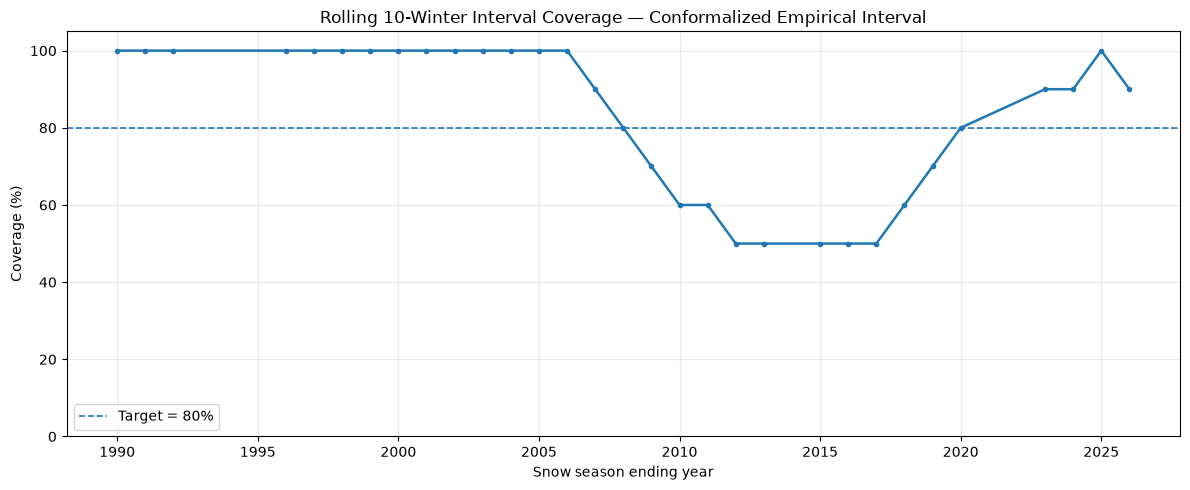

In [10]:

selected_backtest = calibrated[
    calibrated["method"]
    == SELECTED_INTERVAL_METHOD
].copy()

selected_backtest["rolling_10_coverage"] = (
    selected_backtest["inside_interval"]
    .rolling(
        window=10,
        min_periods=5
    )
    .mean()
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    selected_backtest["season_year"],
    selected_backtest["rolling_10_coverage"] * 100,
    linewidth=1.8,
    marker="o",
    markersize=3,
)

ax.axhline(
    80,
    linestyle="--",
    linewidth=1.2,
    label="Target = 80%"
)

ax.set_title(
    f"Rolling 10-Winter Interval Coverage — {SELECTED_INTERVAL_METHOD}"
)
ax.set_xlabel("Snow season ending year")
ax.set_ylabel("Coverage (%)")
ax.set_ylim(0, 105)
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()

fig.savefig(
    FIGURES_DIR
    / "part_b_calibrated_interval_rolling_coverage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 9. Compare original vs calibrated interval widths

In [11]:

selected = calibrated[
    calibrated["method"]
    == SELECTED_INTERVAL_METHOD
].copy()

comparison_rows = pd.DataFrame([
    {
        "interval": "Original empirical 80%",
        "coverage": original_coverage,
        "mean_width_cm": original_width,
    },
    {
        "interval": SELECTED_INTERVAL_METHOD,
        "coverage": selected["inside_interval"].mean(),
        "mean_width_cm": selected["interval_width_cm"].mean(),
    },
])

display(
    comparison_rows.style.format({
        "coverage": "{:.1%}",
        "mean_width_cm": "{:.1f}",
    })
)


,interval,coverage,mean_width_cm
0,Original empirical 80%,68.0%,81.2
1,Conformalized Empirical Interval,82.9%,94.9


## 10. Fit final calibration amount using all completed backtest winters

In [12]:

# For the future forecast, every completed historical backtest winter is now
# available to calibrate the next interval.

if SELECTED_INTERVAL_METHOD == "Conformalized Empirical Interval":
    FINAL_QHAT_CM = conformal_quantile(
        clim["interval_nonconformity_cm"],
        alpha=ALPHA
    )

elif SELECTED_INTERVAL_METHOD == "Symmetric Point-Error Conformal":
    FINAL_QHAT_CM = conformal_quantile(
        clim["absolute_point_error_cm"],
        alpha=ALPHA
    )

else:
    raise ValueError(
        f"Unknown interval method: {SELECTED_INTERVAL_METHOD}"
    )

print(
    "Final calibration q-hat:",
    f"{FINAL_QHAT_CM:.1f} cm"
)


Final calibration q-hat: 6.7 cm


## 11. Calibrate the next-season snowfall outlook

In [13]:

next_outlook = pd.read_csv(
    NEXT_OUTLOOK_PATH
)

if len(next_outlook) != 1:
    raise ValueError(
        "Expected exactly one next-season outlook row."
    )

row = next_outlook.iloc[0].copy()

season_year = int(
    row["season_year"]
)

point_cm = float(
    row["expected_snowfall_cm"]
)

original_lower = float(
    row["lower80_cm"]
)

original_upper = float(
    row["upper80_cm"]
)

if SELECTED_INTERVAL_METHOD == "Conformalized Empirical Interval":
    calibrated_lower = (
        original_lower
        - FINAL_QHAT_CM
    )
    calibrated_upper = (
        original_upper
        + FINAL_QHAT_CM
    )

elif SELECTED_INTERVAL_METHOD == "Symmetric Point-Error Conformal":
    calibrated_lower = (
        point_cm
        - FINAL_QHAT_CM
    )
    calibrated_upper = (
        point_cm
        + FINAL_QHAT_CM
    )

# Snowfall cannot be negative.
calibrated_lower = max(
    0.0,
    calibrated_lower
)

calibrated_outlook = next_outlook.copy()

calibrated_outlook[
    "original_lower80_cm"
] = original_lower

calibrated_outlook[
    "original_upper80_cm"
] = original_upper

calibrated_outlook[
    "calibration_method"
] = SELECTED_INTERVAL_METHOD

calibrated_outlook[
    "conformal_qhat_cm"
] = FINAL_QHAT_CM

calibrated_outlook[
    "calibrated_lower80_cm"
] = calibrated_lower

calibrated_outlook[
    "calibrated_upper80_cm"
] = calibrated_upper

calibrated_outlook[
    "calibrated_width_cm"
] = (
    calibrated_upper
    - calibrated_lower
)

display(
    calibrated_outlook.style.format({
        "expected_snowfall_cm": "{:.1f}",
        "median_snowfall_cm": "{:.1f}",
        "original_lower80_cm": "{:.1f}",
        "original_upper80_cm": "{:.1f}",
        "conformal_qhat_cm": "{:.1f}",
        "calibrated_lower80_cm": "{:.1f}",
        "calibrated_upper80_cm": "{:.1f}",
        "calibrated_width_cm": "{:.1f}",
        "p_below": "{:.1%}",
        "p_near": "{:.1%}",
        "p_above": "{:.1%}",
    })
)


,season_year,method,expected_snowfall_cm,median_snowfall_cm,lower80_cm,upper80_cm,below_normal_threshold_cm,above_normal_threshold_cm,p_below,p_near,p_above,original_lower80_cm,original_upper80_cm,calibration_method,conformal_qhat_cm,calibrated_lower80_cm,calibrated_upper80_cm,calibrated_width_cm
0,2027,Probabilistic Climatology,117.1,124.8,65.340000,154.630000,95.400000,138.433333,33.3%,33.3%,33.3%,65.3,154.6,Conformalized Empirical Interval,6.7,58.7,161.3,102.6



## 12. Important interpretation

The calibrated interval is **not a guarantee** that Toronto snowfall will land inside it.

It means:

> using the historical walk-forward error process and the selected conformal calibration rule, the interval was adjusted toward the intended long-run coverage.

The below / near / above-normal probabilities remain the production **climatological tercile probabilities** because the ML challenger did not demonstrate enough probabilistic skill to replace them.


## 13. Save calibration outputs

In [14]:

CALIBRATED_BACKTEST_PATH = (
    PROCESSED_DIR
    / "calibrated_interval_walk_forward.csv"
)

CALIBRATION_COMPARISON_PATH = (
    PROCESSED_DIR
    / "interval_calibration_comparison.csv"
)

CALIBRATED_OUTLOOK_PATH = (
    PROCESSED_DIR
    / "next_season_calibrated_outlook.csv"
)

METADATA_PATH = (
    MODELS_DIR
    / "interval_calibration_metadata.json"
)

calibrated.to_csv(
    CALIBRATED_BACKTEST_PATH,
    index=False
)

calibration_comparison.to_csv(
    CALIBRATION_COMPARISON_PATH,
    index=False
)

calibrated_outlook.to_csv(
    CALIBRATED_OUTLOOK_PATH,
    index=False
)

metadata = {
    "target_coverage": TARGET_COVERAGE,
    "alpha": ALPHA,
    "minimum_calibration_winters": MIN_CALIBRATION,
    "selected_interval_method": SELECTED_INTERVAL_METHOD,
    "final_qhat_cm": FINAL_QHAT_CM,
    "original_backtest_coverage": float(original_coverage),
    "selected_backtest_coverage": float(
        selected["inside_interval"].mean()
    ),
    "selected_mean_width_cm": float(
        selected["interval_width_cm"].mean()
    ),
}

with open(
    METADATA_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metadata,
        f,
        indent=2
    )

print("Saved:")
print(CALIBRATED_BACKTEST_PATH)
print(CALIBRATION_COMPARISON_PATH)
print(CALIBRATED_OUTLOOK_PATH)
print(METADATA_PATH)


Saved:
/Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis/data/processed/calibrated_interval_walk_forward.csv
/Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis/data/processed/interval_calibration_comparison.csv
/Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis/data/processed/next_season_calibrated_outlook.csv
/Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis/models/interval_calibration_metadata.json


## 14. Generate final calibrated forecast report

In [15]:

report = [
    "# Toronto Seasonal Snowfall — Interval Calibration Report",
    "",
    f"- Nominal target coverage: {TARGET_COVERAGE:.0%}",
    f"- Original empirical interval coverage: {original_coverage:.1%}",
    f"- Original mean width: {original_width:.1f} cm",
    "",
    "## Calibration methods",
    "",
]

for _, r in calibration_comparison.iterrows():
    report.append(
        f"- {r['method']}: "
        f"coverage={r['coverage']:.1%}, "
        f"mean width={r['mean_width_cm']:.1f} cm, "
        f"mean q-hat={r['mean_qhat_cm']:.1f} cm"
    )

report.extend([
    "",
    "## Selected method",
    "",
    f"**{SELECTED_INTERVAL_METHOD}**",
    "",
    f"- Final q-hat: {FINAL_QHAT_CM:.1f} cm",
    "",
    "## Next-season calibrated baseline",
    "",
    f"- Season ending year: {season_year}",
    f"- Expected snowfall: {point_cm:.1f} cm",
    f"- Original nominal interval: {original_lower:.1f}–{original_upper:.1f} cm",
    f"- Calibrated interval: {calibrated_lower:.1f}–{calibrated_upper:.1f} cm",
    f"- Below-normal probability: {float(row['p_below']):.1%}",
    f"- Near-normal probability: {float(row['p_near']):.1%}",
    f"- Above-normal probability: {float(row['p_above']):.1%}",
    "",
    "The calibrated interval reflects historical walk-forward forecast errors. "
    "It should be interpreted as uncertainty calibration, not as a deterministic snowfall range.",
])

REPORT_PATH = (
    REPORTS_DIR
    / "part_b_interval_calibration_report.md"
)

REPORT_PATH.write_text(
    "\n".join(report),
    encoding="utf-8"
)

print(REPORT_PATH.read_text())


# Toronto Seasonal Snowfall — Interval Calibration Report

- Nominal target coverage: 80%
- Original empirical interval coverage: 68.0%
- Original mean width: 81.2 cm

## Calibration methods

- Conformalized Empirical Interval: coverage=82.9%, mean width=94.9 cm, mean q-hat=7.8 cm
- Symmetric Point-Error Conformal: coverage=82.9%, mean width=103.3 cm, mean q-hat=51.7 cm

## Selected method

**Conformalized Empirical Interval**

- Final q-hat: 6.7 cm

## Next-season calibrated baseline

- Season ending year: 2027
- Expected snowfall: 117.1 cm
- Original nominal interval: 65.3–154.6 cm
- Calibrated interval: 58.7–161.3 cm
- Below-normal probability: 33.3%
- Near-normal probability: 33.3%
- Above-normal probability: 33.3%

The calibrated interval reflects historical walk-forward forecast errors. It should be interpreted as uncertainty calibration, not as a deterministic snowfall range.



# Modeling research complete

After this notebook, the research/modeling section of Part B is complete:

```text
snowfall target
    ✅

quality control
    ✅

ENSO / NAO / climate features
    ✅

walk-forward point forecasting
    ✅

climatology benchmark
    ✅

probabilistic forecasting
    ✅

probability evaluation
    ✅

interval calibration
    ✅
```

## Next phase — production system

The next work is no longer model research.

It is the operational system:

```text
new ENSO / NAO / autumn weather data
        ↓
refresh features
        ↓
generate forecast
        ↓
compare with previous forecast
        ↓
material change?
        ↓
agent-written report
        ↓
email + dashboard
```

And after each completed winter:

```text
actual snowfall arrives
        ↓
retrain.py
        ↓
champion vs challenger
        ↓
skill gate
        ↓
promote only if better
        ↓
agent-generated retraining report
        ↓
email
```
